In [1]:
import pandas as pd
import numpy as np
print("pandas version:", pd.__version__)
print("All good!")

pandas version: 2.0.3
All good!


In [5]:
import os
print(os.getcwd())

/Users/spoorthy


In [6]:
postings = pd.read_csv('Desktop/skill-gap-ml/data/postings.csv', usecols=['job_id', 'title', 'description'])
job_skills = pd.read_csv('Desktop/skill-gap-ml/data/job_skills.csv')
skills = pd.read_csv('Desktop/skill-gap-ml/data/skills.csv')
salaries = pd.read_csv('Desktop/skill-gap-ml/data/salaries.csv')

print("Postings:", postings.shape)
print("Job Skills:", job_skills.shape)
print("Skills:", skills.shape)
print("Salaries:", salaries.shape)

Postings: (123849, 3)
Job Skills: (213768, 2)
Skills: (35, 2)
Salaries: (40785, 8)


In [7]:
# Let's see what each table looks like
print("=== POSTINGS (first 3 rows) ===")
print(postings.head(3))
print()
print("=== JOB SKILLS (first 5 rows) ===")
print(job_skills.head(5))
print()
print("=== SKILLS (all 35) ===")
print(skills)

=== POSTINGS (first 3 rows) ===
     job_id                              title  \
0    921716              Marketing Coordinator   
1   1829192  Mental Health Therapist/Counselor   
2  10998357        Assitant Restaurant Manager   

                                         description  
0  Job descriptionA leading real estate firm in N...  
1  At Aspen Therapy and Wellness , we are committ...  
2  The National Exemplar is accepting application...  

=== JOB SKILLS (first 5 rows) ===
       job_id skill_abr
0  3884428798      MRKT
1  3884428798        PR
2  3884428798       WRT
3  3887473071      SALE
4  3887465684       FIN

=== SKILLS (all 35) ===
   skill_abr              skill_name
0        ART            Art/Creative
1       DSGN                  Design
2       ADVR             Advertising
3       PRDM      Product Management
4       DIST            Distribution
5        EDU               Education
6       TRNG                Training
7       PRJM      Project Management
8       CN

In [8]:
# Step 1: merge postings with job_skills on job_id
merged = postings.merge(job_skills, on='job_id', how='inner')
print("After merging postings + job_skills:", merged.shape)

# Step 2: merge with skills to get full skill names
merged = merged.merge(skills, on='skill_abr', how='inner')
print("After merging with skills:", merged.shape)

print()
print("Sample of merged data:")
print(merged[['title', 'skill_abr', 'skill_name']].head(10))

After merging postings + job_skills: (205778, 4)
After merging with skills: (205778, 5)

Sample of merged data:
                                   title skill_abr skill_name
0                  Marketing Coordinator      MRKT  Marketing
1       Senior Product Marketing Manager      MRKT  Marketing
2         Content Writer, Communications      MRKT  Marketing
3      Blog writer and virtual assistant      MRKT  Marketing
4                   Marketing Specialist      MRKT  Marketing
5  Sales Associate Natural Food Products      MRKT  Marketing
6               Social Media Coordinator      MRKT  Marketing
7               Social Media Coordinator      MRKT  Marketing
8                  Marketing Coordinator      MRKT  Marketing
9               Digital Marketing Intern      MRKT  Marketing


In [9]:
# Define tech job keywords
tech_keywords = ['data scientist', 'data analyst', 'machine learning', 
                 'software engineer', 'software developer', 'frontend', 
                 'backend', 'full stack', 'devops', 'data engineer', 
                 'ml engineer', 'python developer', 'java developer']

# Filter rows where title contains any of these keywords (case insensitive)
mask = merged['title'].str.lower().str.contains('|'.join(tech_keywords), na=False)
tech_df = merged[mask].copy()

print("Tech job rows:", len(tech_df))
print()
print("Top 15 job titles:")
print(tech_df['title'].value_counts().head(15))

Tech job rows: 6207

Top 15 job titles:
title
Software Engineer             369
Senior Software Engineer      278
Data Analyst                  244
Software Developer            155
Frontend Developer            138
Data Engineer                 105
Data Scientist                103
DevOps Engineer               102
Full Stack Engineer            90
Java Developer                 69
Python Developer               65
Online Data Analyst            60
Embedded Software Engineer     51
Senior Data Engineer           45
Machine Learning Engineer      43
Name: count, dtype: int64


In [10]:
# Map messy titles to clean category labels
def categorize_title(title):
    title = title.lower()
    if 'data scientist' in title:
        return 'Data Scientist'
    elif 'data analyst' in title:
        return 'Data Analyst'
    elif 'data engineer' in title:
        return 'Data Engineer'
    elif 'machine learning' in title or 'ml engineer' in title:
        return 'ML Engineer'
    elif 'devops' in title:
        return 'DevOps Engineer'
    elif 'frontend' in title or 'front-end' in title:
        return 'Frontend Developer'
    elif 'backend' in title or 'back-end' in title:
        return 'Backend Developer'
    elif 'full stack' in title or 'fullstack' in title:
        return 'Full Stack Developer'
    elif 'python developer' in title:
        return 'Python Developer'
    elif 'java developer' in title:
        return 'Java Developer'
    elif 'software engineer' in title or 'software developer' in title:
        return 'Software Engineer'
    else:
        return 'Other'

tech_df['category'] = tech_df['title'].apply(categorize_title)

print("Job categories distribution:")
print(tech_df['category'].value_counts())

Job categories distribution:
category
Software Engineer       2591
Data Analyst             615
Full Stack Developer     575
Data Engineer            488
Data Scientist           452
DevOps Engineer          419
ML Engineer              265
Java Developer           237
Backend Developer        226
Frontend Developer       216
Python Developer         123
Name: count, dtype: int64


In [11]:
# For each job, get ALL skills as a list
# group by job_id + title + category, collect all skill_names into a list
job_profiles = tech_df.groupby(['job_id', 'title', 'category'])['skill_name'].apply(list).reset_index()
job_profiles.columns = ['job_id', 'title', 'category', 'skills']

# Convert list of skills to a single string (needed for TF-IDF)
job_profiles['skills_text'] = job_profiles['skills'].apply(lambda x: ' '.join(x))

print("Unique job postings:", len(job_profiles))
print()
print("Sample rows:")
print(job_profiles[['title', 'category', 'skills_text']].head(8))

Unique job postings: 3579

Sample rows:
                                  title              category  \
0                     Software Engineer     Software Engineer   
1                     Software Engineer     Software Engineer   
2                   Full Stack Engineer  Full Stack Developer   
3  Java architect / Lead Java developer        Java Developer   
4              Senior Software Engineer     Software Engineer   
5            Principal Backend Engineer     Backend Developer   
6                backend Java developer     Backend Developer   
7     Cloud Platform/ Big Data Engineer         Data Engineer   

                          skills_text  
0  Information Technology Engineering  
1  Information Technology Engineering  
2  Information Technology Engineering  
3  Information Technology Engineering  
4  Information Technology Engineering  
5  Information Technology Engineering  
6  Information Technology Engineering  
7                         Engineering  


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Convert skills text to numbers using TF-IDF
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(job_profiles['skills_text'])
y = job_profiles['category']

print("Feature matrix shape:", X.shape)
print("This means:", X.shape[0], "job postings,", X.shape[1], "unique skill features")
print()

# Step 2: Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print()

# Step 3: Train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained!")

Feature matrix shape: (3579, 46)
This means: 3579 job postings, 46 unique skill features

Training samples: 2863
Testing samples: 716

Model trained!


In [13]:
# Test the model on the 20% it has never seen before
y_pred = model.predict(X_test)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print()

# Detailed breakdown per role
print("Per-role breakdown:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 46.93%

Per-role breakdown:
                      precision    recall  f1-score   support

   Backend Developer       0.00      0.00      0.00        31
        Data Analyst       0.76      0.36      0.49        80
       Data Engineer       0.28      0.74      0.41        72
      Data Scientist       0.00      0.00      0.00        42
     DevOps Engineer       0.44      0.08      0.14        50
  Frontend Developer       0.00      0.00      0.00        17
Full Stack Developer       0.00      0.00      0.00        59
      Java Developer       0.00      0.00      0.00        30
         ML Engineer       0.10      0.04      0.05        28
    Python Developer       0.00      0.00      0.00        11
   Software Engineer       0.54      0.84      0.66       296

            accuracy                           0.47       716
           macro avg       0.19      0.19      0.16       716
        weighted avg       0.37      0.47      0.38       716



/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

In [14]:
# Use description text instead of just skill names
# First clean the description text
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # remove special characters
    text = re.sub(r'\s+', ' ', text)            # remove extra spaces
    return text.strip()

# Get one row per job (descriptions are same across skill rows)
job_profiles['clean_desc'] = job_profiles['job_id'].map(
    tech_df.drop_duplicates('job_id').set_index('job_id')['description'].apply(clean_text)
)

# Combine description + skills for richer features
job_profiles['combined'] = job_profiles['clean_desc'] + ' ' + job_profiles['skills_text']

print("Sample combined text (first 300 chars):")
print(job_profiles['combined'].iloc[0][:300])

Sample combined text (first 300 chars):
education bachelor s degree in software math or science required job skills analytical skills group work knowledge of intended audience understanding of different roles Information Technology Engineering


In [15]:
# Step 1: TF-IDF on combined text (description + skills)
# max_features=500 means use only top 500 most important words
tfidf_v2 = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2))
X2 = tfidf_v2.fit_transform(job_profiles['combined'])
y2 = job_profiles['category']

print("New feature matrix shape:", X2.shape)
print()

# Step 2: Split again
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Step 3: Retrain with better settings
model_v2 = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model_v2.fit(X_train2, y_train2)

# Step 4: Evaluate
y_pred2 = model_v2.predict(X_test2)
accuracy2 = accuracy_score(y_test2, y_pred2)
print(f"New Accuracy: {accuracy2 * 100:.2f}%")
print()
print(classification_report(y_test2, y_pred2, zero_division=0))

New feature matrix shape: (3579, 500)

New Accuracy: 78.35%

                      precision    recall  f1-score   support

   Backend Developer       0.92      0.39      0.55        31
        Data Analyst       0.92      0.91      0.92        80
       Data Engineer       0.87      0.86      0.87        72
      Data Scientist       0.79      0.74      0.77        42
     DevOps Engineer       0.89      0.78      0.83        50
  Frontend Developer       1.00      0.59      0.74        17
Full Stack Developer       0.87      0.34      0.49        59
      Java Developer       0.69      0.30      0.42        30
         ML Engineer       0.72      0.64      0.68        28
    Python Developer       0.83      0.45      0.59        11
   Software Engineer       0.72      0.95      0.82       296

            accuracy                           0.78       716
           macro avg       0.84      0.63      0.70       716
        weighted avg       0.80      0.78      0.77       716



In [16]:
import pickle

# Save the model and tfidf vectorizer
with open('skill_gap_model.pkl', 'wb') as f:
    pickle.dump(model_v2, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_v2, f)

print("Model saved as skill_gap_model.pkl")
print("Vectorizer saved as tfidf_vectorizer.pkl")
print()

# Quick test - predict a sample
sample = ["python machine learning data analysis sql statistics pandas numpy"]
sample_vec = tfidf_v2.transform(sample)
prediction = model_v2.predict(sample_vec)
probability = model_v2.predict_proba(sample_vec).max()

print(f"Test prediction: '{sample[0]}'")
print(f"Predicted role: {prediction[0]}")
print(f"Confidence: {probability*100:.1f}%")

Model saved as skill_gap_model.pkl
Vectorizer saved as tfidf_vectorizer.pkl

Test prediction: 'python machine learning data analysis sql statistics pandas numpy'
Predicted role: Data Scientist
Confidence: 30.2%


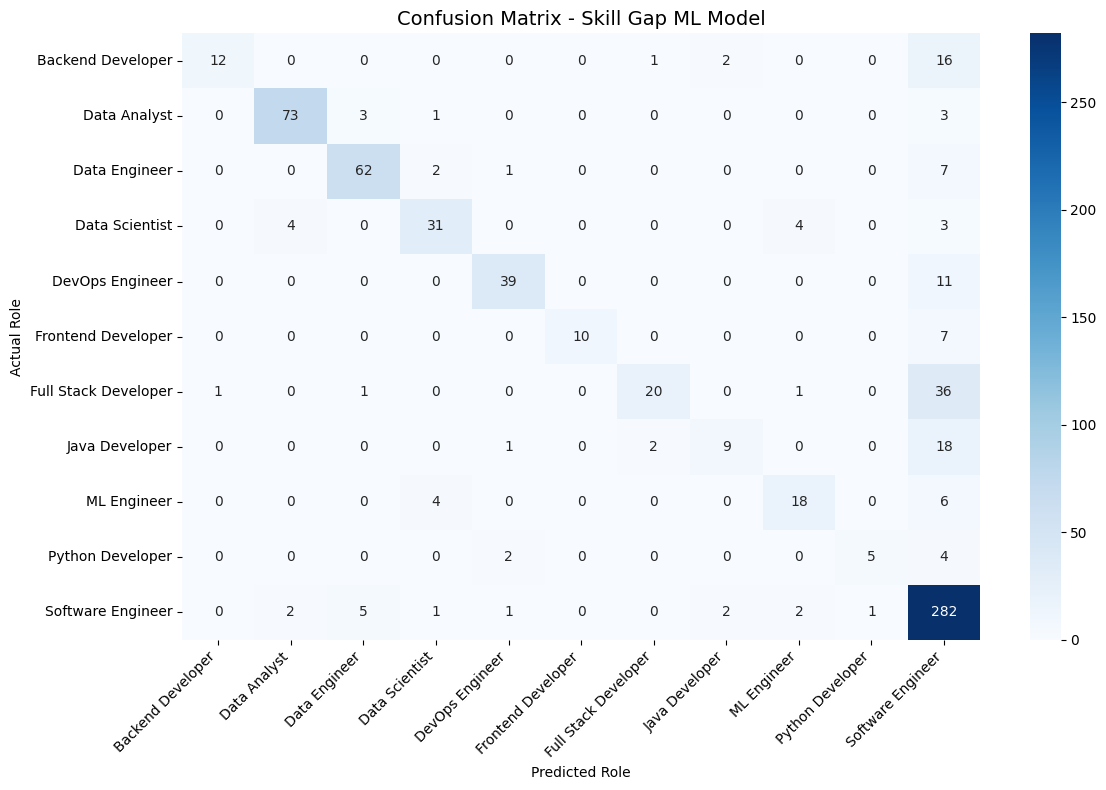

Saved as confusion_matrix.png


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix - shows where the model gets confused
cm = confusion_matrix(y_test2, y_pred2, labels=model_v2.classes_)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=model_v2.classes_,
            yticklabels=model_v2.classes_)
plt.title('Confusion Matrix - Skill Gap ML Model', fontsize=14)
plt.ylabel('Actual Role')
plt.xlabel('Predicted Role')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved as confusion_matrix.png")

In [23]:
import os
print(os.getcwd())

/Users/spoorthy
